# Day 03：多头视野 —— 为什么一个脑袋不够用> 🚀 第十一周 · 注意力时代 · 第 3 天昨天我们学会了缩放点积注意力。但有一个问题：**一次注意力只能关注一种关系模式。**就像你只有一双眼睛——你可以看语法关系，或者看语义关系，但不能同时看两种。解决方案：**多长几双眼睛**——这就是多头注意力（Multi-Head Attention）。**今天的任务**：1. 理解多头注意力的动机：同时关注不同类型的关系2. 手写多头注意力层3. 可视化不同"头"关注的模式---

## 1. 历史剧场：2017 年 Transformer 的"多眼怪兽"2017 年，Vaswani 等人在《Attention Is All You Need》中提出了多头注意力：> **与其用一个大的注意力，不如用多个小的注意力并行计算，然后拼接结果。**每个"头"独立学习自己的 Q、K、V 投影，因此可以关注不同类型的关系：- 头 1 可能关注语法关系（主语-谓语）- 头 2 可能关注语义关系（同义词）- 头 3 可能关注位置关系（相邻的词）---

## 2. 生活隐喻：多个侦探同时调查想象你在调查一桩案件：- **侦探 A**（头 1）：专门调查时间线——谁在什么时候做了什么- **侦探 B**（头 2）：专门调查人际关系——谁和谁有联系- **侦探 C**（头 3）：专门调查动机——为什么这么做每个侦探独立调查（并行），最后汇总报告（拼接 + 线性变换）。**单头注意力**：只有一个侦探，只能关注一种线索**多头注意力**：多个侦探同时关注不同线索，信息更全面---

<p align="center">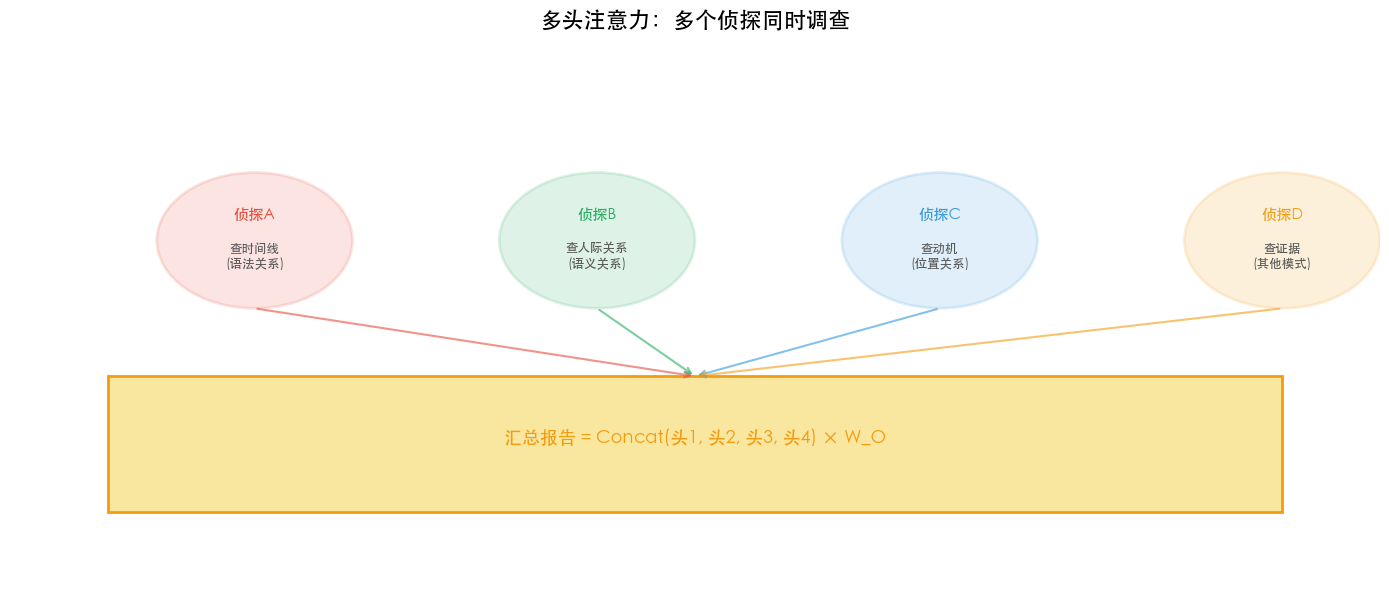</p>*多头注意力侦探隐喻图*

## 3. 数学直觉：多头注意力### 3.1 单头 vs 多头**单头**：$$\text{head} = \text{Attention}(QW_Q, KW_K, VW_V)$$**多头**：$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W_O$$其中每个头：$$\text{head}_i = \text{Attention}(QW_Q^i, KW_K^i, VW_V^i)$$### 3.2 维度设计如果模型维度 $d_{model} = 512$，头数 $h = 8$：- 每个头的维度：$d_k = d_v = d_{model} / h = 64$- 每个头独立计算注意力- 8 个头的输出拼接后变回 $d_{model} = 512$- 最后通过 $W_O$ 做线性变换**关键**：多头注意力的总计算量和单头差不多，但能捕捉多种关系模式。---

## 4. 代码实验室：手写多头注意力

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写多头注意力

In [ ]:
class MultiHeadAttention:    def __init__(self, d_model, n_heads):        self.d_model = d_model        self.n_heads = n_heads        self.d_k = d_model // n_heads        self.W_Qs = [np.random.randn(d_model, self.d_k) * np.sqrt(2.0/d_model)                     for _ in range(n_heads)]        self.W_Ks = [np.random.randn(d_model, self.d_k) * np.sqrt(2.0/d_model)                     for _ in range(n_heads)]        self.W_Vs = [np.random.randn(d_model, self.d_k) * np.sqrt(2.0/d_model)                     for _ in range(n_heads)]        self.W_O = np.random.randn(d_model, d_model) * np.sqrt(2.0/d_model)    def softmax(self, x):        exp_x = np.exp(x - x.max(axis=-1, keepdims=True))        return exp_x / exp_x.sum(axis=-1, keepdims=True)    def forward(self, X):        seq_len = X.shape[0]        head_outputs = []        head_weights = []        for i in range(self.n_heads):            Q = X @ self.W_Qs[i]            K = X @ self.W_Ks[i]            V = X @ self.W_Vs[i]            scores = Q @ K.T / np.sqrt(self.d_k)            attn = self.softmax(scores)            head_out = attn @ V            head_outputs.append(head_out)            head_weights.append(attn)        concat = np.concatenate(head_outputs, axis=-1)        output = concat @ self.W_O        return output, head_weightsnp.random.seed(42)d_model = 8n_heads = 4seq_len = 6X = np.random.randn(seq_len, d_model)mha = MultiHeadAttention(d_model, n_heads)output, head_weights = mha.forward(X)print(f"输入: {X.shape}")print(f"每个头的维度: {mha.d_k}")print(f"头数: {n_heads}")print(f"拼接后: {d_model}")print(f"输出: {output.shape}")

### 4.2 可视化不同头的注意力模式

In [ ]:
fig, axes = plt.subplots(1, n_heads, figsize=(5*n_heads, 4))labels = [f'词{i+1}' for i in range(seq_len)]for i, (ax, weights) in enumerate(zip(axes, head_weights)):    im = ax.imshow(weights, aspect='auto', cmap='YlOrRd', vmin=0)    ax.set_title(f'头 {i+1}', fontsize=13)    ax.set_xticks(range(seq_len))    ax.set_xticklabels(labels, fontsize=9)    ax.set_yticks(range(seq_len))    ax.set_yticklabels(labels, fontsize=9)    plt.colorbar(im, ax=ax, fraction=0.046)plt.suptitle('多头注意力：不同的头关注不同的模式', fontsize=15, y=1.05)plt.tight_layout()plt.show()

### 解读每个头的注意力模式都不同：- 有的头关注对角线（每个词关注自己）- 有的头关注相邻位置（局部关系）- 有的头关注远距离位置（全局关系）这就是多头注意力的力量——**不同的头自动学习关注不同类型的关系**。---

## 5. 多头 vs 单头：参数量对比

In [ ]:
print("单头 vs 多头：参数量对比\n")d_model = 512n_heads = 8d_k = d_model // n_headssingle_head_params = d_model * d_k * 3 + d_model * d_modelmulti_head_params = n_heads * (d_model * d_k * 3) + d_model * d_modelprint(f"模型维度: {d_model}")print(f"单头 (d_k={d_model}): {single_head_params:,} 参数")print(f"多头 (h={n_heads}, d_k={d_k}): {multi_head_params:,} 参数")print(f"\n关键: 参数量几乎相同，但多头能捕捉多种关系模式！")

---

## 今日结语多头注意力让模型同时关注不同类型的关系——就像多个侦探同时调查不同线索。每个头独立学习自己的 Q、K、V 投影，捕捉不同的注意力模式。多个头的输出拼接后通过线性变换融合。参数量和单头几乎相同，但信息更丰富。这就是 Transformer 的核心组件。明天，我们将学习 Transformer 的另一个关键创新：位置编码。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 多个侦探同时调查 | 多头注意力——并行关注不同关系 || 侦探 A 查时间线，侦探 B 查关系 | 不同头学习不同的注意力模式 || 汇总所有侦探的报告 | Concat + 线性变换——融合多头输出 || 参数量几乎不变 | 多头和单头的计算量相当 || 一双眼睛看一种关系 | 单头注意力——只能关注一种模式 |